# Loading the dataset

## Import Required Libraries
Import necessary libraries for data analysis, including pandas and numpy.

In [16]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

## Extract Dataset
Extract the dataset from the compressed zip file.

In [17]:
import zipfile
import os

# Extract the dataset from the zip file
zip_file_path = 'ag-news-classification-dataset.zip'
extract_path = './ag-news-classification-dataset'

# Check if the dataset has already been extracted
if os.path.exists(extract_path):
    print("Dataset already extracted. Skipping extraction.")
else:
    # Extract only if the folder doesn't exist
    if os.path.exists(zip_file_path):
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall('./')
        print("Dataset extracted successfully!")
    else:
        print(f"Zip file not found at {zip_file_path}")

# List extracted files
extracted_files = os.listdir('./')
print("\nExtracted files:")
for file in extracted_files:
    print(f"  - {file}")

Dataset already extracted. Skipping extraction.

Extracted files:
  - .DS_Store
  - Untitled-1.ipynb
  - .gitkeep
  - playbook.pdf
  - playbook.ipynb
  - README.md
  - .gitignore
  - ag-news-classification-dataset.zip
  - .git
  - ag-news-classification-dataset


## Load Dataset into DataFrame
Load the AG News dataset into a Pandas DataFrame for analysis.

In [18]:
# Find all CSV files in the extracted directory
csv_files = [f for f in os.listdir('./ag-news-classification-dataset') if f.endswith('.csv')]
print(f"Found {len(csv_files)} CSV file(s): {csv_files}\n")

# Load all CSV files into dataframes
dataframes = {}
if csv_files:
    for csv_file in csv_files:
        file_path = os.path.join('./ag-news-classification-dataset', csv_file)
        file_name = csv_file.replace('.csv', '')  # Get name without extension
        dataframes[file_name] = pd.read_csv(file_path)
        print(f"Loaded '{csv_file}' with shape: {dataframes[file_name].shape}")
    
    # Create convenient references for train and test data
    df_train = dataframes.get('train', None)
    df_test = dataframes.get('test', None)
    print("\nDataframes created:")
    print(f"  - df_train: {df_train.shape if df_train is not None else 'Not found'}")
    print(f"  - df_test: {df_test.shape if df_test is not None else 'Not found'}")
else:
    print("No CSV files found. Please check the extracted files.")
    df_train = None
    df_test = None

Found 2 CSV file(s): ['test.csv', 'train.csv']

Loaded 'test.csv' with shape: (7600, 3)
Loaded 'train.csv' with shape: (120000, 3)

Dataframes created:
  - df_train: (120000, 3)
  - df_test: (7600, 3)


## Dataset Overview
Display the basic information and structure of the loaded dataset.

In [19]:
def display_dataframe_info(df, name):
    """Display detailed information about a dataframe"""
    print(f"\n{'='*60}")
    print(f"DATASET: {name}")
    print(f"{'='*60}")
    print(f"Shape: {df.shape}")
    
    print("\n" + "="*60)
    print("First Few Rows:")
    print("="*60)
    print(df.head())
    
    print("\n" + "="*60)
    print("Column Information:")
    print("="*60)
    print(df.info())
    
    print("\n" + "="*60)
    print("Summary Statistics:")
    print("="*60)
    print(df.describe())
    
    print("\n" + "="*60)
    print("Missing Values:")
    print("="*60)
    print(df.isnull().sum())

# Display info for all loaded datasets
if df_train is not None:
    display_dataframe_info(df_train, "Training Data")

if df_test is not None:
    display_dataframe_info(df_test, "Test Data")

if df_train is None and df_test is None:
    print("No datasets loaded successfully.")


DATASET: Training Data
Shape: (120000, 3)

First Few Rows:
   Class Index                                              Title  \
0            3  Wall St. Bears Claw Back Into the Black (Reuters)   
1            3  Carlyle Looks Toward Commercial Aerospace (Reu...   
2            3    Oil and Economy Cloud Stocks' Outlook (Reuters)   
3            3  Iraq Halts Oil Exports from Main Southern Pipe...   
4            3  Oil prices soar to all-time record, posing new...   

                                         Description  
0  Reuters - Short-sellers, Wall Street's dwindli...  
1  Reuters - Private investment firm Carlyle Grou...  
2  Reuters - Soaring crude prices plus worries\ab...  
3  Reuters - Authorities have halted oil export\f...  
4  AFP - Tearaway world oil prices, toppling reco...  

Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       ----

# Exploratory Data Analysis (EDA)

## Class Distribution
Analyze the distribution of news categories in both training and test datasets.

In [20]:
import matplotlib.pyplot as plt

# Define class mapping
class_mapping = {
    1: "World",
    2: "Sports", 
    3: "Business",
    4: "Science/Technology"
}

# Function to display class distribution
def analyze_class_distribution(df, name):
    """Analyze and visualize class distribution"""
    print(f"\n{'='*60}")
    print(f"CLASS DISTRIBUTION: {name}")
    print(f"{'='*60}")
    
    # Count classes
    class_counts = df['Class Index'].value_counts().sort_index()
    class_percentages = (class_counts / len(df) * 100).round(2)
    
    # Display statistics
    print(f"\nClass Counts:")
    for class_idx in sorted(class_counts.index):
        count = class_counts[class_idx]
        percentage = class_percentages[class_idx]
        class_name = class_mapping.get(class_idx, f"Class {class_idx}")
        print(f"  {class_idx} - {class_name}: {count:,} ({percentage}%)")
    
    return class_counts, class_percentages

# Analyze training data
train_counts, train_percentages = analyze_class_distribution(df_train, "Training Data")

# Analyze test data
test_counts, test_percentages = analyze_class_distribution(df_test, "Test Data")


CLASS DISTRIBUTION: Training Data

Class Counts:
  1 - World: 30,000 (25.0%)
  2 - Sports: 30,000 (25.0%)
  3 - Business: 30,000 (25.0%)
  4 - Science/Technology: 30,000 (25.0%)

CLASS DISTRIBUTION: Test Data

Class Counts:
  1 - World: 1,900 (25.0%)
  2 - Sports: 1,900 (25.0%)
  3 - Business: 1,900 (25.0%)
  4 - Science/Technology: 1,900 (25.0%)


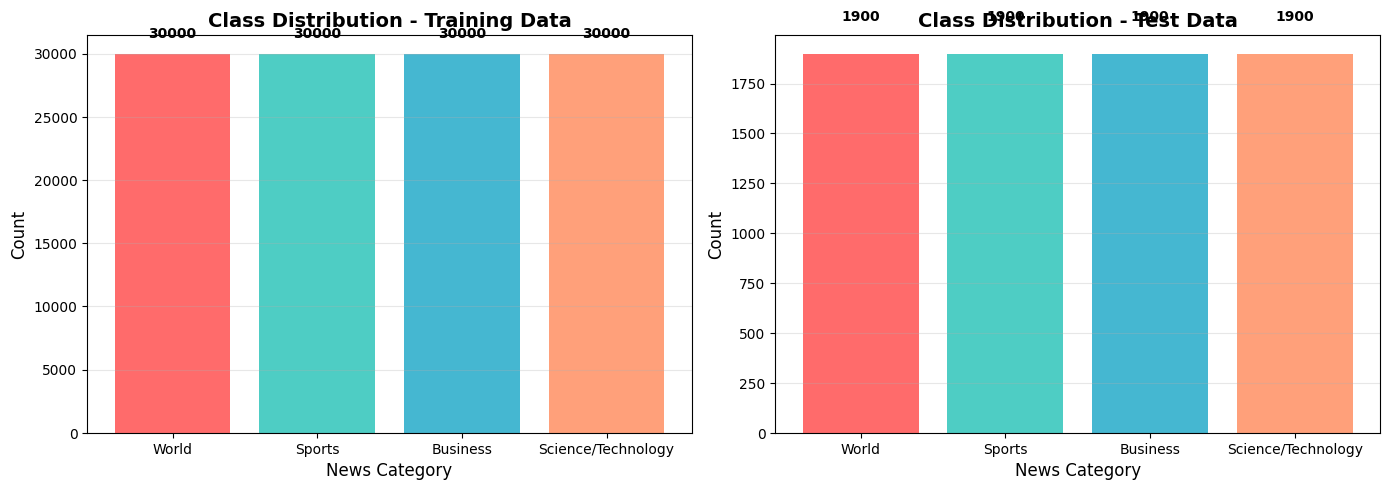


✓ Class distribution analysis complete!


In [21]:
# Create visualization for class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot training data distribution
class_labels = [class_mapping.get(i, f"Class {i}") for i in sorted(train_counts.index)]
axes[0].bar(class_labels, train_counts.values, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'])
axes[0].set_title('Class Distribution - Training Data', fontsize=14, fontweight='bold')
axes[0].set_xlabel('News Category', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(train_counts.values):
    axes[0].text(i, v + 1000, str(v), ha='center', va='bottom', fontweight='bold')

# Plot test data distribution
class_labels_test = [class_mapping.get(i, f"Class {i}") for i in sorted(test_counts.index)]
axes[1].bar(class_labels_test, test_counts.values, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'])
axes[1].set_title('Class Distribution - Test Data', fontsize=14, fontweight='bold')
axes[1].set_xlabel('News Category', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(test_counts.values):
    axes[1].text(i, v + 150, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓ Class distribution analysis complete!")

## Text Length Distribution
Analyze the distribution of text lengths (Title and Description) in both datasets.

In [22]:
# Calculate text lengths for both datasets
def calculate_text_lengths(df, name):
    """Calculate and display text length statistics"""
    print(f"\n{'='*60}")
    print(f"TEXT LENGTH DISTRIBUTION: {name}")
    print(f"{'='*60}")
    
    # Calculate lengths
    df_copy = df.copy()
    df_copy['Title_Length'] = df_copy['Title'].str.len()
    df_copy['Description_Length'] = df_copy['Description'].str.len()
    
    # Display statistics for Title
    print(f"\nTitle Length Statistics:")
    print(f"  Mean: {df_copy['Title_Length'].mean():.2f}")
    print(f"  Median: {df_copy['Title_Length'].median():.2f}")
    print(f"  Min: {df_copy['Title_Length'].min()}")
    print(f"  Max: {df_copy['Title_Length'].max()}")
    print(f"  Std Dev: {df_copy['Title_Length'].std():.2f}")
    
    # Display statistics for Description
    print(f"\nDescription Length Statistics:")
    print(f"  Mean: {df_copy['Description_Length'].mean():.2f}")
    print(f"  Median: {df_copy['Description_Length'].median():.2f}")
    print(f"  Min: {df_copy['Description_Length'].min()}")
    print(f"  Max: {df_copy['Description_Length'].max()}")
    print(f"  Std Dev: {df_copy['Description_Length'].std():.2f}")
    
    return df_copy

# Calculate for both datasets
df_train_text = calculate_text_lengths(df_train, "Training Data")
df_test_text = calculate_text_lengths(df_test, "Test Data")


TEXT LENGTH DISTRIBUTION: Training Data

Title Length Statistics:
  Mean: 42.07
  Median: 41.00
  Min: 6
  Max: 115
  Std Dev: 13.57

Description Length Statistics:
  Mean: 193.39
  Median: 188.00
  Min: 6
  Max: 985
  Std Dev: 64.47

TEXT LENGTH DISTRIBUTION: Test Data

Title Length Statistics:
  Mean: 41.88
  Median: 41.00
  Min: 6
  Max: 96
  Std Dev: 13.48

Description Length Statistics:
  Mean: 192.41
  Median: 187.00
  Min: 37
  Max: 830
  Std Dev: 63.19


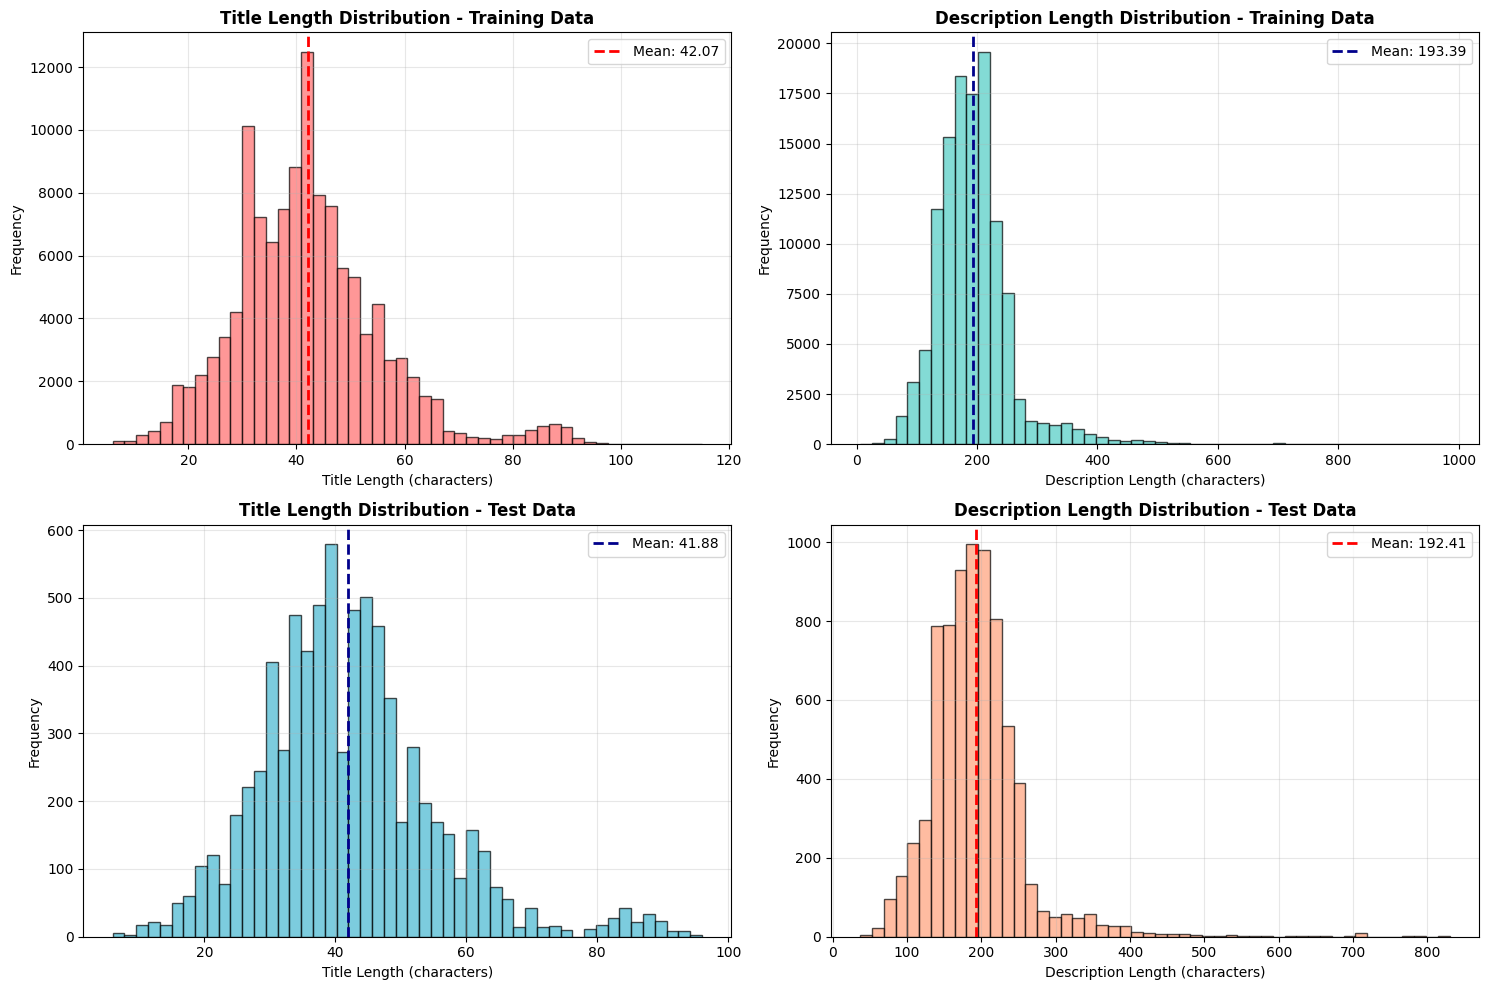


✓ Text length distribution analysis complete!


In [23]:
# Create visualizations for text length distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Training Data - Title Length
axes[0, 0].hist(df_train_text['Title_Length'], bins=50, color='#FF6B6B', alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Title Length Distribution - Training Data', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Title Length (characters)', fontsize=10)
axes[0, 0].set_ylabel('Frequency', fontsize=10)
axes[0, 0].axvline(df_train_text['Title_Length'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df_train_text['Title_Length'].mean():.2f}")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Training Data - Description Length
axes[0, 1].hist(df_train_text['Description_Length'], bins=50, color='#4ECDC4', alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Description Length Distribution - Training Data', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Description Length (characters)', fontsize=10)
axes[0, 1].set_ylabel('Frequency', fontsize=10)
axes[0, 1].axvline(df_train_text['Description_Length'].mean(), color='darkblue', linestyle='--', linewidth=2, label=f"Mean: {df_train_text['Description_Length'].mean():.2f}")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Test Data - Title Length
axes[1, 0].hist(df_test_text['Title_Length'], bins=50, color='#45B7D1', alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Title Length Distribution - Test Data', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Title Length (characters)', fontsize=10)
axes[1, 0].set_ylabel('Frequency', fontsize=10)
axes[1, 0].axvline(df_test_text['Title_Length'].mean(), color='darkblue', linestyle='--', linewidth=2, label=f"Mean: {df_test_text['Title_Length'].mean():.2f}")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Test Data - Description Length
axes[1, 1].hist(df_test_text['Description_Length'], bins=50, color='#FFA07A', alpha=0.7, edgecolor='black')
axes[1, 1].set_title('Description Length Distribution - Test Data', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Description Length (characters)', fontsize=10)
axes[1, 1].set_ylabel('Frequency', fontsize=10)
axes[1, 1].axvline(df_test_text['Description_Length'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df_test_text['Description_Length'].mean():.2f}")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Text length distribution analysis complete!")

## Random Samples
Examine random samples from the dataset to sanity-check labels and assess the informativeness of titles and descriptions.

In [24]:
# Display random samples from both datasets
def display_random_samples(df, name, num_samples=5):
    """Display random samples with class names, titles, and descriptions"""
    print(f"\n{'='*80}")
    print(f"RANDOM SAMPLES: {name}")
    print(f"{'='*80}\n")
    
    # Get random samples
    random_samples = df.sample(n=min(num_samples, len(df)), random_state=42)
    
    for idx, (i, row) in enumerate(random_samples.iterrows(), 1):
        class_idx = row['Class Index']
        class_name = class_mapping.get(class_idx, f"Class {class_idx}")
        
        print(f"Sample {idx}:")
        print(f"  Class: {class_idx} - {class_name}")
        print(f"  Title: {row['Title']}")
        print(f"  Description: {row['Description']}")
        print(f"  Title Length: {len(row['Title'])} chars | Description Length: {len(row['Description'])} chars")
        print(f"  {'-'*76}\n")

# Display random samples from training data
display_random_samples(df_train, "Training Data", num_samples=5)

# Display random samples from test data
display_random_samples(df_test, "Test Data", num_samples=5)

print("✓ Random samples displayed successfully!")


RANDOM SAMPLES: Training Data

Sample 1:
  Class: 3 - Business
  Title: BBC set for major shake-up, claims newspaper
  Description: London - The British Broadcasting Corporation, the world #39;s biggest public broadcaster, is to cut almost a quarter of its 28 000-strong workforce, in the biggest shake-up in its 82-year history, The Times newspaper in London said on Monday.
  Title Length: 44 chars | Description Length: 243 chars
  ----------------------------------------------------------------------------

Sample 2:
  Class: 3 - Business
  Title: Marsh averts cash crunch
  Description: Embattled insurance broker #39;s banks agree to waive clause that may have prevented access to credit. NEW YORK (Reuters) - Marsh  amp; McLennan Cos.
  Title Length: 24 chars | Description Length: 149 chars
  ----------------------------------------------------------------------------

Sample 3:
  Class: 2 - Sports
  Title: Jeter, Yankees Look to Take Control (AP)
  Description: AP - Derek Jeter turned

## Text Preprocessing Pipeline
Combine title and description, apply light cleaning, and tokenize for model input.

In [25]:
import re
import string
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Set seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Combine Title and Description into a single text column
df_train['text'] = df_train['Title'].fillna('') + ' ' + df_train['Description'].fillna('')
df_test['text'] = df_test['Title'].fillna('') + ' ' + df_test['Description'].fillna('')

# Convert 1-based labels to 0-based for PyTorch
df_train['label'] = df_train['Class Index'] - 1
df_test['label'] = df_test['Class Index'] - 1

print(f"Combined text shape: {df_train['text'].shape}")
print(f"Sample combined text (first 200 chars): {df_train['text'].iloc[0][:200]}")
print(f"Label distribution (0-based):\n{df_train['label'].value_counts().sort_index()}")

Combined text shape: (120000,)
Sample combined text (first 200 chars): Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.
Label distribution (0-based):
label
0    30000
1    30000
2    30000
3    30000
Name: count, dtype: int64


In [26]:
# Light text cleaning function suitable for news text
def clean_text(text):
    """
    Apply light cleaning to text:
    - Convert to lowercase
    - Remove HTML entities (&#39;, &amp;, etc.)
    - Remove URLs
    - Remove extra whitespace
    """
    # Convert to string if needed
    text = str(text)
    
    # Lowercase
    text = text.lower()
    
    # Remove HTML entities like &#39; &amp; etc.
    text = re.sub(r'&#?\w+;', '', text)
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # Remove escaped backslashes and special escape sequences
    text = text.replace('\\', ' ')
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Apply cleaning to both datasets
df_train['text_clean'] = df_train['text'].apply(clean_text)
df_test['text_clean'] = df_test['text'].apply(clean_text)

print("✓ Text cleaning complete!")
print(f"\nSample original: {df_train['text'].iloc[0][:150]}")
print(f"\nSample cleaned:  {df_train['text_clean'].iloc[0][:150]}")

✓ Text cleaning complete!

Sample original: Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.

Sample cleaned:  wall st. bears claw back into the black (reuters) reuters - short-sellers, wall street's dwindling band of ultra-cynics, are seeing green again.


In [27]:
# Simple word tokenizer and vocabulary builder
class SimpleTokenizer:
    def __init__(self):
        self.vocab = {'<PAD>': 0, '<UNK>': 1}  # Reserved tokens
        self.word2idx = self.vocab.copy()
        self.idx2word = {v: k for k, v in self.word2idx.items()}
    
    def build_vocab(self, texts, min_freq=1):
        """Build vocabulary from a list of texts (training set only)"""
        word_freq = {}
        for text in texts:
            for word in text.split():
                word_freq[word] = word_freq.get(word, 0) + 1
        
        # Add words that appear at least min_freq times
        idx = 2  # Start after PAD and UNK
        for word, freq in sorted(word_freq.items(), key=lambda x: x[1], reverse=True):
            if freq >= min_freq:
                self.word2idx[word] = idx
                self.idx2word[idx] = word
                idx += 1
        
        print(f"Vocabulary size: {len(self.word2idx)}")
    
    def encode(self, text):
        """Convert text to list of integer indices"""
        tokens = text.split()
        return [self.word2idx.get(token, self.word2idx['<UNK>']) for token in tokens]
    
    def decode(self, indices):
        """Convert list of indices back to text"""
        return ' '.join([self.idx2word.get(idx, '<UNK>') for idx in indices])

# Build vocabulary from training set only
tokenizer = SimpleTokenizer()
tokenizer.build_vocab(df_train['text_clean'])

print(f"✓ Tokenizer initialized with vocab size: {len(tokenizer.word2idx)}")

Vocabulary size: 146410
✓ Tokenizer initialized with vocab size: 146410


In [28]:
# Convert text to padded sequences
def text_to_sequences(texts, tokenizer, max_len=150):
    """Convert texts to padded sequences"""
    sequences = []
    for text in texts:
        seq = tokenizer.encode(text)
        # Truncate or pad to max_len
        if len(seq) >= max_len:
            seq = seq[:max_len]
        else:
            seq = seq + [tokenizer.word2idx['<PAD>']] * (max_len - len(seq))
        sequences.append(seq)
    return torch.tensor(sequences, dtype=torch.long)

# Set max sequence length (based on average description length observed)
MAX_LEN = 150

# Convert training and test sets to padded sequences
X_train = text_to_sequences(df_train['text_clean'], tokenizer, MAX_LEN)
y_train = torch.tensor(df_train['label'].values, dtype=torch.long)

X_test = text_to_sequences(df_test['text_clean'], tokenizer, MAX_LEN)
y_test = torch.tensor(df_test['label'].values, dtype=torch.long)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"✓ Sequences padded to length {MAX_LEN}")

X_train shape: torch.Size([120000, 150])
y_train shape: torch.Size([120000])
X_test shape: torch.Size([7600, 150])
y_test shape: torch.Size([7600])
✓ Sequences padded to length 150


In [29]:
# PyTorch Dataset class
class AGNewsDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        return {
            'text': self.texts[idx],
            'label': self.labels[idx]
        }

# Create datasets and dataloaders
BATCH_SIZE = 32

train_dataset = AGNewsDataset(X_train, y_train)
test_dataset = AGNewsDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"✓ DataLoaders created")
print(f"  Training batches: {len(train_loader)}")
print(f"  Test batches: {len(test_loader)}")
print(f"  Batch size: {BATCH_SIZE}")

✓ DataLoaders created
  Training batches: 3750
  Test batches: 238
  Batch size: 32


In [30]:
# Define BiLSTM model for text classification
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, hidden_dim=128, num_classes=4, dropout_rate=0.3):
        super(BiLSTMClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=2,
            bidirectional=True,
            dropout=dropout_rate,
            batch_first=True
        )
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)  # *2 for bidirectional
    
    def forward(self, x):
        # x shape: (batch_size, seq_len)
        embedded = self.embedding(x)  # (batch_size, seq_len, embed_dim)
        embedded = self.dropout(embedded)
        
        # LSTM output: (batch_size, seq_len, hidden_dim * 2)
        lstm_out, (hidden, cell) = self.lstm(embedded)
        
        # Use the last hidden states from both directions
        # hidden shape after bilstm: (2 * num_layers, batch_size, hidden_dim)
        # We take the last layer's both directions
        hidden_fwd = hidden[-2]  # Last forward direction hidden state
        hidden_bwd = hidden[-1]  # Last backward direction hidden state
        hidden_combined = torch.cat([hidden_fwd, hidden_bwd], dim=1)  # (batch_size, hidden_dim * 2)
        
        hidden_combined = self.dropout(hidden_combined)
        logits = self.fc(hidden_combined)  # (batch_size, num_classes)
        
        return logits

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Initialize model
VOCAB_SIZE = len(tokenizer.word2idx)
EMBED_DIM = 100
HIDDEN_DIM = 128
NUM_CLASSES = 4
DROPOUT_RATE = 0.3

model = BiLSTMClassifier(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_classes=NUM_CLASSES,
    dropout_rate=DROPOUT_RATE
).to(device)

print(f"\n✓ BiLSTM model initialized")
print(f"  Vocab size: {VOCAB_SIZE}")
print(f"  Embedding dim: {EMBED_DIM}")
print(f"  Hidden dim: {HIDDEN_DIM}")
print(f"  Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Using device: cpu

✓ BiLSTM model initialized
  Vocab size: 146410
  Embedding dim: 100
  Hidden dim: 128
  Model parameters: 15,272,812


In [31]:
# Training setup
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=1, verbose=True
)

def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch in train_loader:
        texts = batch['text'].to(device)
        labels = batch['label'].to(device)
        
        # Forward pass
        logits = model(texts)
        loss = criterion(logits, labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Metrics
        total_loss += loss.item()
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    epoch_loss = total_loss / len(train_loader)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def eval_epoch(model, test_loader, criterion, device):
    """Evaluate on test set"""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in test_loader:
            texts = batch['text'].to(device)
            labels = batch['label'].to(device)
            
            logits = model(texts)
            loss = criterion(logits, labels)
            
            total_loss += loss.item()
            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = total_loss / len(test_loader)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc, all_preds, all_labels

# Training loop
NUM_EPOCHS = 5
print("Starting training...\n")

train_losses = []
train_accs = []
test_losses = []
test_accs = []

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc, _, _ = eval_epoch(model, test_loader, criterion, device)
    
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)
    
    scheduler.step(test_loss)
    
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Test Loss:  {test_loss:.4f} | Test Acc:  {test_acc:.4f}\n")

print("✓ Training complete!")

Starting training...

Epoch 1/5
  Train Loss: 0.5679 | Train Acc: 0.7884
  Test Loss:  0.3453 | Test Acc:  0.8813

Epoch 2/5
  Train Loss: 0.3123 | Train Acc: 0.8929
  Test Loss:  0.2757 | Test Acc:  0.9092

Epoch 3/5
  Train Loss: 0.2454 | Train Acc: 0.9164
  Test Loss:  0.2527 | Test Acc:  0.9158

Epoch 4/5
  Train Loss: 0.2011 | Train Acc: 0.9314
  Test Loss:  0.2503 | Test Acc:  0.9201

Epoch 5/5
  Train Loss: 0.1710 | Train Acc: 0.9415
  Test Loss:  0.2425 | Test Acc:  0.9229

✓ Training complete!


FINAL EVALUATION ON TEST SET

Test Accuracy: 0.9229
Test Macro F1: 0.9227

Classification Report:
              precision    recall  f1-score   support

       World     0.9344    0.9295    0.9319      1900
      Sports     0.9624    0.9826    0.9724      1900
    Business     0.8845    0.8984    0.8914      1900
    Sci/Tech     0.9098    0.8811    0.8952      1900

    accuracy                         0.9229      7600
   macro avg     0.9228    0.9229    0.9227      7600
weighted avg     0.9228    0.9229    0.9227      7600


Confusion Matrix (0-based indices):
[[1766   38   63   33]
 [  15 1867   13    5]
 [  50   15 1707  128]
 [  59   20  147 1674]]


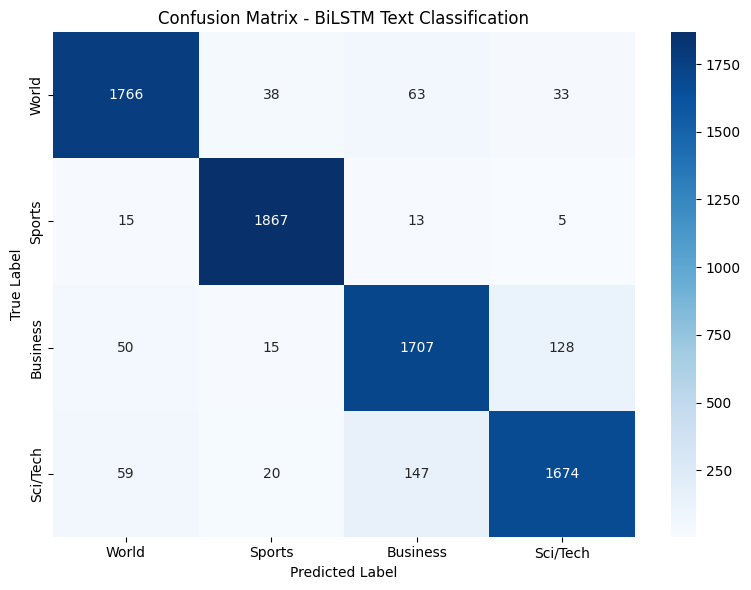


✓ Evaluation complete!


In [32]:
# Final evaluation on test set
print("=" * 80)
print("FINAL EVALUATION ON TEST SET")
print("=" * 80 + "\n")

test_loss, test_acc, all_preds, all_labels = eval_epoch(model, test_loader, criterion, device)

# Convert 0-based indices back to 1-based class labels for reporting
all_preds_1based = [p + 1 for p in all_preds]
all_labels_1based = [l + 1 for l in all_labels]

# Calculate metrics
accuracy = accuracy_score(all_labels, all_preds)
macro_f1 = f1_score(all_labels, all_preds, average='macro')

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Macro F1: {macro_f1:.4f}\n")

# Classification report
print("Classification Report:")
print(classification_report(
    all_labels_1based, all_preds_1based,
    target_names=['World', 'Sports', 'Business', 'Sci/Tech'],
    digits=4
))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

print("\nConfusion Matrix (0-based indices):")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['World', 'Sports', 'Business', 'Sci/Tech'],
            yticklabels=['World', 'Sports', 'Business', 'Sci/Tech'])
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix - BiLSTM Text Classification')
plt.tight_layout()
plt.show()

print("\n✓ Evaluation complete!")

In [33]:
# Show sample predictions from test set
print("=" * 80)
print("SAMPLE PREDICTIONS FROM TEST SET")
print("=" * 80 + "\n")

model.eval()

# Get indices of correct and incorrect predictions
correct_mask = np.array(all_preds) == np.array(all_labels)
incorrect_indices = np.where(~correct_mask)[0]

class_mapping_display = {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}

# Show a few correct predictions
print("✓ CORRECT PREDICTIONS (samples):\n")
for i in range(min(3, len(np.where(correct_mask)[0]))):
    idx = np.where(correct_mask)[0][i]
    test_row_idx = idx  # Index in test set
    
    if test_row_idx < len(df_test):
        true_label = all_labels[idx]
        pred_label = all_preds[idx]
        
        print(f"Sample {i+1}:")
        print(f"  Title: {df_test.iloc[test_row_idx]['Title'][:70]}")
        print(f"  True Class: {class_mapping_display[true_label]} | Predicted: {class_mapping_display[pred_label]}")
        print(f"  {'-'*76}\n")

# Show a few incorrect predictions
if len(incorrect_indices) > 0:
    print("✗ INCORRECT PREDICTIONS (samples):\n")
    for i in range(min(3, len(incorrect_indices))):
        idx = incorrect_indices[i]
        true_label = all_labels[idx]
        pred_label = all_preds[idx]
        
        if idx < len(df_test):
            print(f"Sample {i+1}:")
            print(f"  Title: {df_test.iloc[idx]['Title'][:70]}")
            print(f"  True Class: {class_mapping_display[true_label]} | Predicted: {class_mapping_display[pred_label]}")
            print(f"  {'-'*76}\n")
else:
    print("✓ Perfect predictions! No errors found.")

print("✓ Sample predictions displayed!")

SAMPLE PREDICTIONS FROM TEST SET

✓ CORRECT PREDICTIONS (samples):

Sample 1:
  Title: Fears for T N pension after talks
  True Class: Business | Predicted: Business
  ----------------------------------------------------------------------------

Sample 2:
  Title: The Race is On: Second Private Team Sets Launch Date for Human Spacefl
  True Class: Sci/Tech | Predicted: Sci/Tech
  ----------------------------------------------------------------------------

Sample 3:
  Title: Ky. Company Wins Grant to Study Peptides (AP)
  True Class: Sci/Tech | Predicted: Sci/Tech
  ----------------------------------------------------------------------------

✗ INCORRECT PREDICTIONS (samples):

Sample 1:
  Title: Prediction Unit Helps Forecast Wildfires (AP)
  True Class: Sci/Tech | Predicted: Sports
  ----------------------------------------------------------------------------

Sample 2:
  Title: E-mail scam targets police chief
  True Class: Sci/Tech | Predicted: World
  -----------------------------